### 1. Data Loading and Cleaning...

The current state of the Air Quality Data is as follows : 

- We are using the European standard for csv : where we use semi-colons(;) instead of commas(,) to separate different column values and also we use commas(,) instead of decimal points(.) for decimal values....

Example : 
Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2,6;1360;150;11,9;1046;166;1056;113;1692;1268;13,6;48,9;0,7578;;

In [3]:
import pandas as pd
import numpy as np

#A. LOAD THE DATA : Loading the raw sensor data into a pandas DataFrame considering special rules and translating ; to , for separators and , to . for decimal points

raw_sensor_data = pd.read_csv(r"Dataset\AirQuality.csv", sep= ";", decimal=",")

#Printing a Preview of the new Data
raw_sensor_data.loc[0: 5, :]

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,NaN,NaN


C:\Users\DELL\AppData\Local\Temp\ipykernel_15944\4050440766.py:25: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  raw_sensor_data.interpolate(inplace=True)


<Axes: title={'center': 'Raw Sensor Data'}, xlabel='DateTime'>

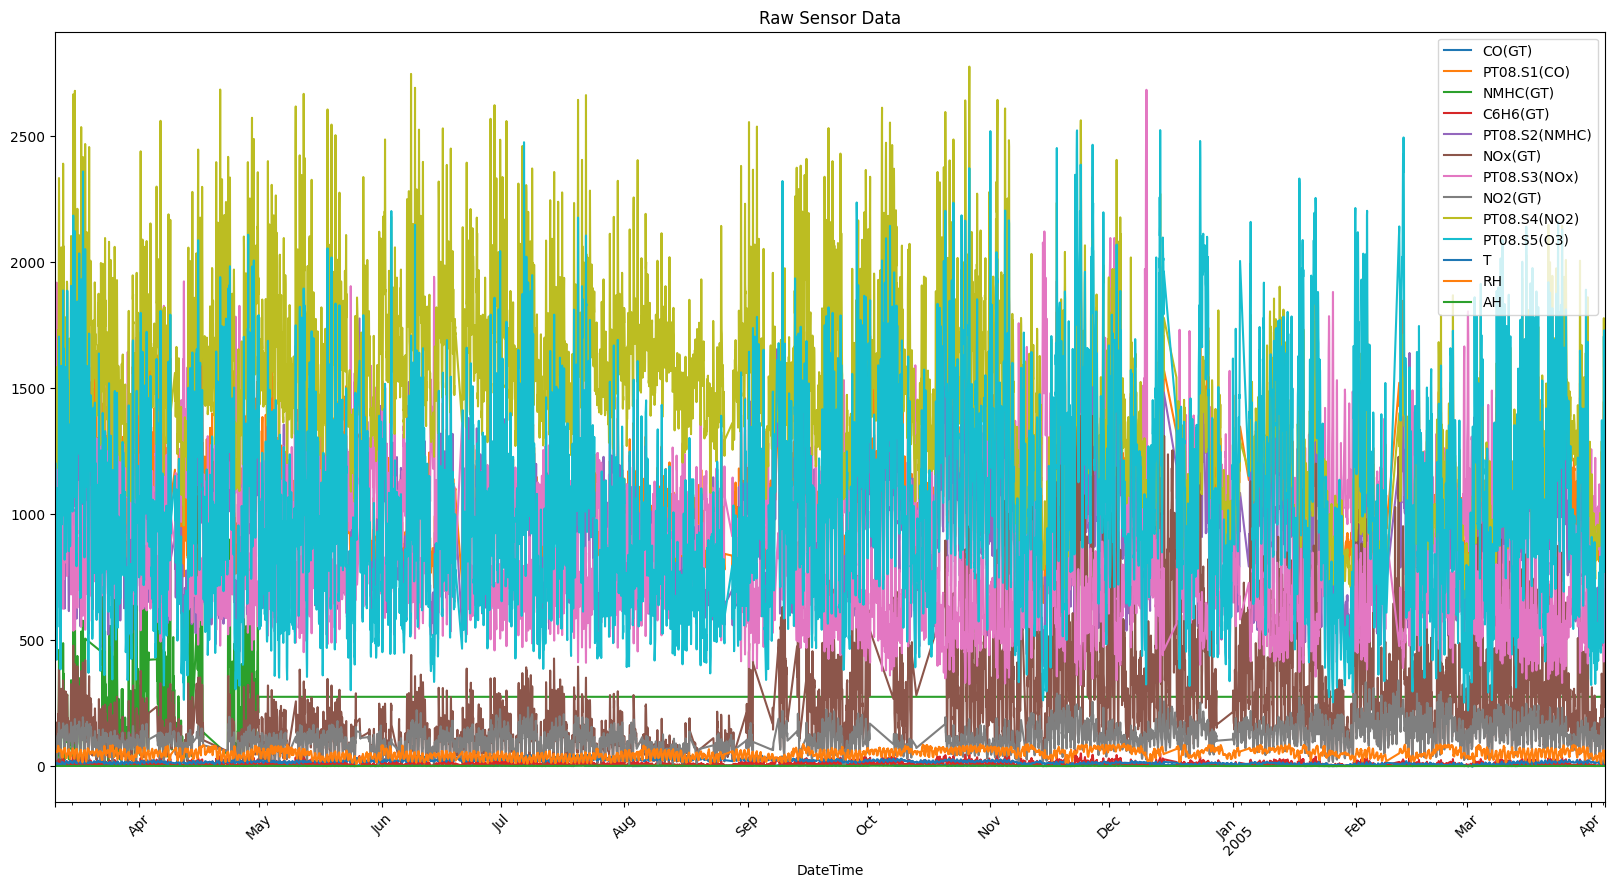

In [4]:
#CLEANING THE DATA :

#Removing Empty Columns
raw_sensor_data = raw_sensor_data.loc[ : , "Date" : "AH"].copy()

#Remove Rows where Date and Time were not recorded because they are essentially useless readings that cannot be pointed to a particular time... 
raw_sensor_data.dropna(subset=["Date", "Time"], inplace=True)

#The sensors return an error code `-200` when it encountered an error, to combat this, we would be replacing any -200 error code with NaN = np.nan
raw_sensor_data.replace(-200, np.nan, inplace=True)

#Format Time data from HH.MM.SS to HH:MM:SS
raw_sensor_data["Time"]= raw_sensor_data["Time"].str.replace(".", ":")

#Create a raw DataTime column that combines Date and Time
raw_sensor_data["DateTime_temp"] = raw_sensor_data["Date"] + raw_sensor_data["Time"]

#Convert the DateTime series dtype into the pandas datetime64 datatype
raw_sensor_data["DateTime"]= pd.to_datetime(raw_sensor_data["DateTime_temp"], format="%d/%m/%Y%H:%M:%S")

#Now make the new DateTime column the row label or index...
raw_sensor_data = raw_sensor_data.set_index("DateTime")

#For NaN values in the Data Related columns, we would use interpolation to fill them up
raw_sensor_data.interpolate(inplace=True)

raw_sensor_data

raw_sensor_data.plot(rot= 45, title="Raw Sensor Data", figsize=(20, 10))


### 2. Feature Engineering and Extraction 

In [5]:
# Feature Engineering 

#Time Based Features: 
#a. Hour of the Day
raw_sensor_data["Hour_of_Day"] = raw_sensor_data.index.hour

#b. Day of the Week
raw_sensor_data["Day_of_Week"] = raw_sensor_data.index.weekday

#c. Is Weekend?
raw_sensor_data["Is_Weekend"] = np.where(raw_sensor_data.index.weekday >= 5, 1, 0)

#d. Month of the Year
raw_sensor_data["Month"] = raw_sensor_data.index.month
 
# Weather Based Features : 
#e. T(Temperature) 
#f. AH(Absolute Humidity)


# Lag Features : A lag feature simply takes a piece of data from a previous time step and copies it into the current row so the model can look at it. Enabling Short Term Memory
#Firstly sorting the data 
raw_sensor_data.sort_index(inplace=True)

#Create Lag 1 and 2  for each pollutant 
raw_sensor_data["CO_Lag2"] = raw_sensor_data["CO(GT)"].shift(2)
raw_sensor_data["CO_Lag3"] = raw_sensor_data["CO(GT)"].shift(3)

raw_sensor_data["NMHC_Lag1"] = raw_sensor_data["NMHC(GT)"].shift(1)
raw_sensor_data["NMHC_Lag2"] = raw_sensor_data["NMHC(GT)"].shift(2)

raw_sensor_data["C6H6_Lag1"] = raw_sensor_data["C6H6(GT)"].shift(1)
raw_sensor_data["C6H6_Lag2"] = raw_sensor_data["C6H6(GT)"].shift(2)

raw_sensor_data["NOx_Lag1"] = raw_sensor_data["NOx(GT)"].shift(1)
raw_sensor_data["NOx_Lag2"] = raw_sensor_data["NOx(GT)"].shift(2)

raw_sensor_data["NO2_Lag1"] = raw_sensor_data["NO2(GT)"].shift(1)
raw_sensor_data["NO2_Lag2"] = raw_sensor_data["NO2(GT)"].shift(2)

#Remove rows with empty values in any column
raw_sensor_data = raw_sensor_data.dropna()

raw_sensor_data



,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),...,CO_Lag2,CO_Lag3,NMHC_Lag1,NMHC_Lag2,C6H6_Lag1,C6H6_Lag2,NOx_Lag1,NOx_Lag2,NO2_Lag1,NO2_Lag2
DateTime,,,,,,,,,,,,,,,,,,,,,
2004-03-10 21:00:00,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,...,2.0,2.6,88.0,112.0,9.0,9.4,131.0,103.0,114.0,92.0
2004-03-10 22:00:00,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,...,2.2,2.0,80.0,88.0,9.2,9.0,172.0,131.0,122.0,114.0
2004-03-10 23:00:00,10/03/2004,23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,...,2.2,2.2,51.0,80.0,6.5,9.2,131.0,172.0,116.0,122.0
2004-03-11 00:00:00,11/03/2004,00:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,...,1.6,2.2,38.0,51.0,4.7,6.5,89.0,131.0,96.0,116.0
2004-03-11 01:00:00,11/03/2004,01:00:00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,...,1.2,1.6,31.0,38.0,3.6,4.7,62.0,89.0,77.0,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,04/04/2005,10:00:00,3.1,1314.0,275.0,13.5,1101.0,472.0,539.0,190.0,...,5.0,4.0,275.0,275.0,13.6,22.4,523.0,586.0,187.0,174.0
2005-04-04 11:00:00,04/04/2005,11:00:00,2.4,1163.0,275.0,11.4,1027.0,353.0,604.0,179.0,...,3.9,5.0,275.0,275.0,13.5,13.6,472.0,523.0,190.0,187.0
2005-04-04 12:00:00,04/04/2005,12:00:00,2.4,1142.0,275.0,12.4,1063.0,293.0,603.0,175.0,...,3.1,3.9,275.0,275.0,11.4,13.5,353.0,472.0,179.0,190.0


### 3. Feature Extraction


In [6]:
#Final Clean Up Steps and Feature Extraction

#1. Extracting our Target Values
#We would want to be able to predict CO(GT)
y = raw_sensor_data["CO(GT)"]


#2. Extracting our Design Matrix aka Features
Columns_Needed = list(raw_sensor_data.columns)

Columns_Needed.remove("Date")
Columns_Needed.remove("Time")
Columns_Needed.remove("DateTime_temp")
Columns_Needed.remove("CO(GT)") #Removing the actual label to avoid Data Leakage

for column in Columns_Needed:
    print(column)


#Using the Columns_Needed List to select the Features
X = raw_sensor_data.loc[:, Columns_Needed]


PT08.S1(CO)
NMHC(GT)
C6H6(GT)
PT08.S2(NMHC)
NOx(GT)
PT08.S3(NOx)
NO2(GT)
PT08.S4(NO2)
PT08.S5(O3)
T
RH
AH
Hour_of_Day
Day_of_Week
Is_Weekend
Month
CO_Lag2
CO_Lag3
NMHC_Lag1
NMHC_Lag2
C6H6_Lag1
C6H6_Lag2
NOx_Lag1
NOx_Lag2
NO2_Lag1
NO2_Lag2


### 4. Data Splitting : 

We would be splitting the Data using the 80/20 rule respecting the fact that we are dealing with time series data meaning that we would follow the arrow of time.....

In [7]:
# Train Splitting Percentage
train_split_percentage = 80

# Last check to make sure that the data is sorted according to time
X = X.sort_index()
y = y.sort_index()

# Counting How many Rows are in the data and making sure that the number of rows in the Feature Matrix(DataFrame) is the same as the number of rows in the Target Values Array(Series)...
if X["AH"].count() != y.count():
    raise Exception("Check your code again, the number of Rows in the Feature Matrix and Target Value Series is not the same") 

n_Rows = y.count()

n_train_Rows = round((train_split_percentage/100) * n_Rows)

print(f"We would be using {n_train_Rows} Data points for Training and {n_Rows - n_train_Rows} for Testing")



#DATA SPLITTING
X_train = X.iloc[ : n_train_Rows]
X_test = X.iloc[n_train_Rows : ]

y_train = y.iloc[: n_train_Rows]
y_test = y.iloc[n_train_Rows: ]

We would be using 7483 Data points for Training and 1871 for Testing


### 4. Model Preparation

In [8]:
from sklearn.ensemble import RandomForestRegressor


#Initializing the Model with some manually curated hyperparameters....
model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=5, random_state=42)

model.fit(X_train, y_train)


#Now After training, we would then have to Run the Predictor object which is now the trained version of our initial estimator object on our test data and then get its predictions...
#.fit() fundamentally transformed your object from a generic, structural Estimator into a concrete, knowledgeable Predictor.
y_pred = model.predict(X_test)



<Axes: >

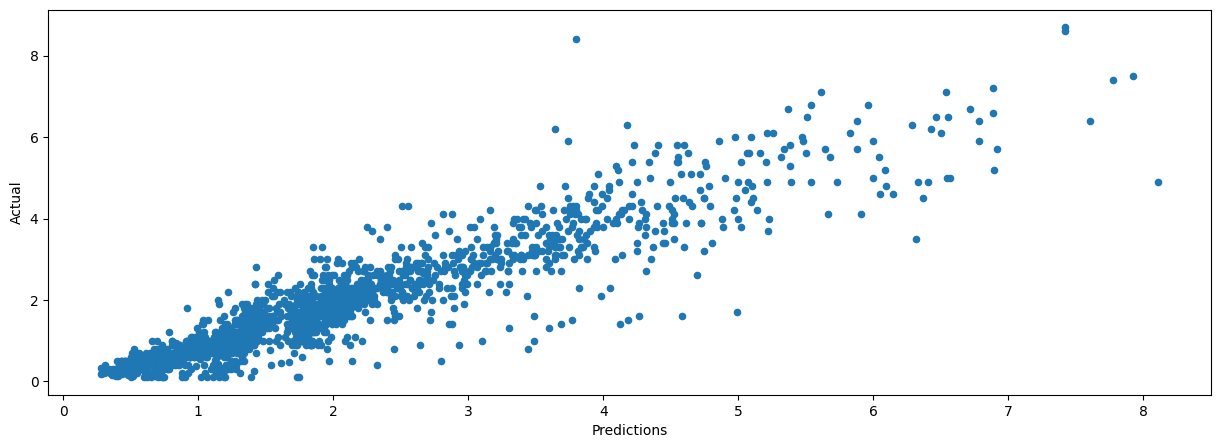

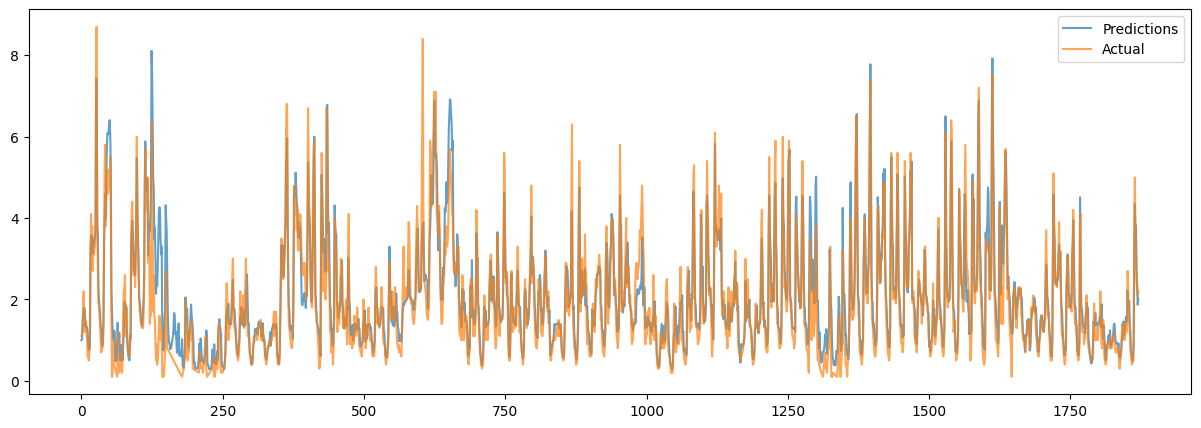

In [9]:
#Let us combine y_pred and y_test to visualize our model's performance 
Combined_Predictions_dict = {
    "Predictions" : y_pred,
    "Actual" : y_test.to_numpy()
}

Combined_Predictions_df = pd.DataFrame(Combined_Predictions_dict)
Combined_Predictions_df
Combined_Predictions_df.plot.scatter(x= "Predictions", y="Actual", figsize=(15,5))
Combined_Predictions_df.plot(figsize=(15,5), alpha= 0.7)

Mean Absolute Error(MAE) : 0.37461499707565477
Mean Squared Error(MSE) : 0.30670361363762294
Root Mean Squared Error(RMSE): 0.5538082823844575
r2 score : 0.839225344005617

Feature PT08.S1(CO) has an importance of 0.09183399525762463
Feature NMHC(GT) has an importance of 0.0037229600746178904
Feature C6H6(GT) has an importance of 0.05050270388354277
Feature PT08.S2(NMHC) has an importance of 0.47218453571681757
Feature NOx(GT) has an importance of 0.13665715720020202
Feature PT08.S3(NOx) has an importance of 0.009643202523130681
Feature NO2(GT) has an importance of 0.05867358061180991
Feature PT08.S4(NO2) has an importance of 0.0048560198507792115
Feature PT08.S5(O3) has an importance of 0.003485628050796115
Feature T has an importance of 0.0023687229910492854
Feature RH has an importance of 0.0011937248406856263
Feature AH has an importance of 0.002510106561448872
Feature Hour_of_Day has an importance of 0.0040133304201152445
Feature Day_of_Week has an importance of 0.0012781599084322

<Axes: xlabel='feature_name'>

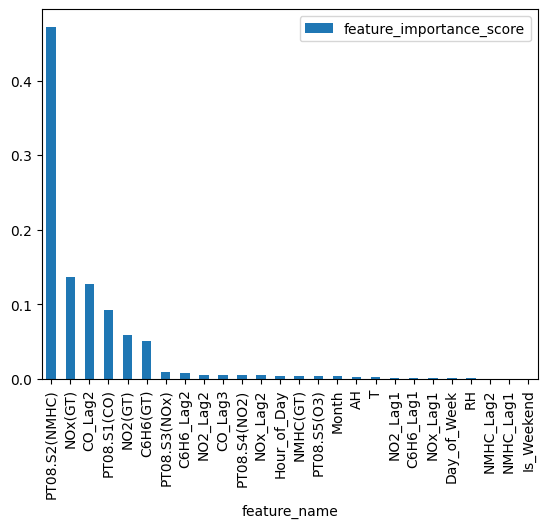

In [10]:
#Evaluating our model 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print(f"Mean Absolute Error(MAE) : {mean_absolute_error(y_true=y_test, y_pred=y_pred)}")
print(f"Mean Squared Error(MSE) : {mean_squared_error(y_true=y_test, y_pred=y_pred)}")
print(f"Root Mean Squared Error(RMSE): {np.sqrt(mean_squared_error(y_true=y_test, y_pred=y_pred))}")
print(f"r2 score : {r2_score(y_true=y_test, y_pred=y_pred)}")

# Checking the Importance of each feature
print()

feature_Importance = model.feature_importances_; 

for index in range(len(feature_Importance)): 
    print(f'Feature {Columns_Needed[index]} has an importance of {feature_Importance[index]}')



feat_imp_dict = {
    "feature_name" : Columns_Needed,
    "feature_importance_score" : feature_Importance
}

feat_imp_df = pd.DataFrame(feat_imp_dict)

feat_imp_df.set_index("feature_importance_score", inplace=True)
feat_imp_df.sort_index(inplace=True, ascending=False)
feat_imp_df.reset_index(inplace=True)

feat_imp_df.plot.bar(x= "feature_name", y="feature_importance_score")

### 5. Hyperparameter tunning using Grid Search 

In [11]:
# Hyperparameter grid creation
parameter_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [5, 8, 10, 12]
}

test_model = RandomForestRegressor()

#We need a Time Series Splitter for our Time Based Dataset to give our Search Algorithm a sense of the Arrow of Time...
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

my_t_splitter = TimeSeriesSplit()


#Let us initiate Grid search object 

my_hyperparameter_search = GridSearchCV(test_model, parameter_grid,scoring="r2", cv=my_t_splitter)

# Run the Grid search and print the best results...
my_hyperparameter_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [12]:
print(my_hyperparameter_search.best_estimator_)
print()
print(my_hyperparameter_search.best_params_)

RandomForestRegressor(max_depth=10, n_estimators=200)

{'max_depth': 10, 'n_estimators': 200}


                           mean_test_score
model_ID                                  
Depth(10) Estimators(200)         0.747895
Depth(10) Estimators(300)         0.747158
Depth(12) Estimators(300)         0.746474
Depth(12) Estimators(100)         0.746313
Depth(10) Estimators(100)         0.744209
Depth(12) Estimators(200)         0.742750
Depth(8) Estimators(300)          0.740812
Depth(8) Estimators(200)          0.740496
Depth(8) Estimators(100)          0.737267
Depth(5) Estimators(100)          0.719261
Depth(5) Estimators(200)          0.716932
Depth(5) Estimators(300)          0.713035


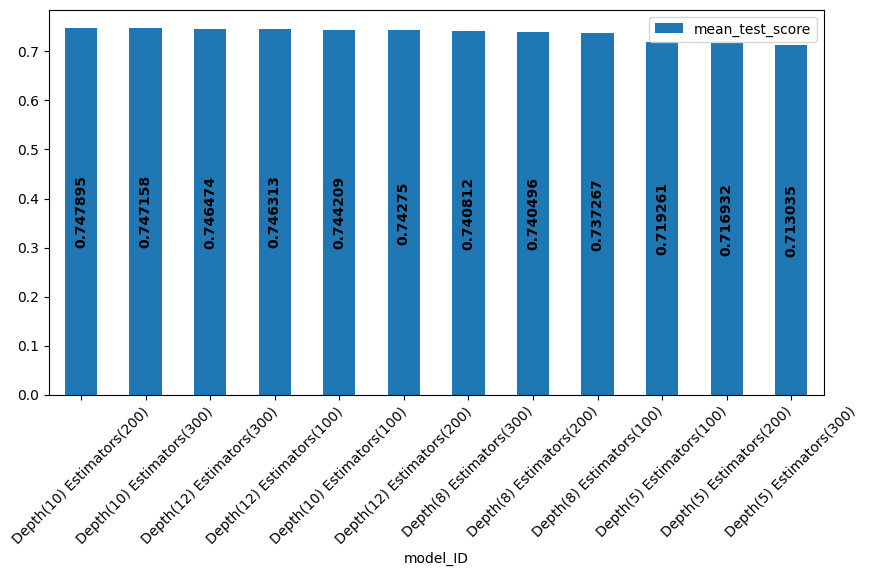

In [13]:
# Creating a chart that shows the results of our Grid Search visually

#1. Getting the entire dictionary containing our results and then turning it into a DataFrame
raw_search_results_dict = my_hyperparameter_search.cv_results_

raw_search_results_df = pd.DataFrame(raw_search_results_dict, dtype=pd.StringDtype()) #We are using the StringDtype dtype so that we can work with them as strings and use it to create a name directly...

#2. Selecting the columns we really need
raw_search_results_df = raw_search_results_df.loc[:, ["param_max_depth", "param_n_estimators", "mean_test_score"]]

#3. Creating Unique Names for each model

raw_search_results_df["model_ID"] = "Depth(" + raw_search_results_df["param_max_depth"] + ") Estimators(" + raw_search_results_df["param_n_estimators"] + ")"

#4. Deleting the Raw Parameters columns....
raw_search_results_df = raw_search_results_df.loc[:, ["mean_test_score", "model_ID"]]

raw_search_results_df["mean_test_score"] = raw_search_results_df["mean_test_score"].astype(float)

#5. Sorting according to the test scores
raw_search_results_df.sort_values(by = "mean_test_score", inplace= True, ascending=False)


raw_search_results_df.set_index("model_ID", inplace=True)

print(raw_search_results_df)

search_plot = raw_search_results_df.plot.bar(figsize= (10,5), rot=45, y="mean_test_score")

for bar in search_plot.containers:
    search_plot.bar_label(bar, label_type="center", weight="bold", rotation=90)

Best (Depth(10) Estimators(200)) Mean Absolute Error : 0.3522357833750685
Best (Depth(10) Estimators(200)) Mean Square Error : 0.2886928108871338
Best (Depth(10) Estimators(200)) Root Mean Square Error : 0.5373014153034903
Best (Depth(10) Estimators(200)) R2 Score : 0.8486666433175118


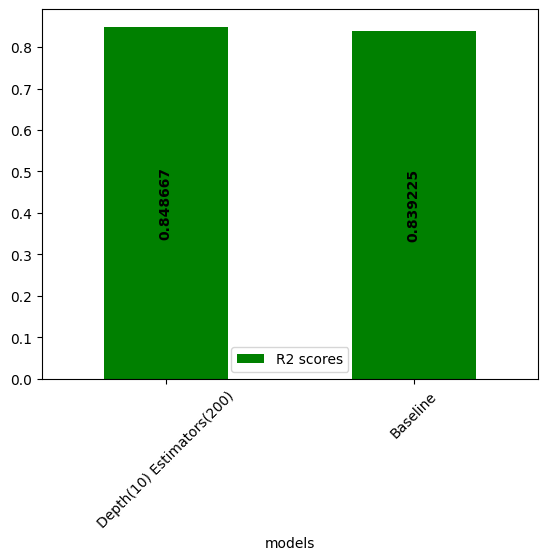

In [ ]:
# Comparing Our Base line model with the best model from our search

#Best Model from search 
best_estimator_from_search = my_hyperparameter_search.best_estimator_

# Best Search Result Model score : Test the best estimator from the Grid Search
y_grid_pred = best_estimator_from_search.predict(X_test)
best_search_score = r2_score(y_pred=y_grid_pred, y_true=y_test)

#Base Line model's score 
baseline_score = r2_score(y_pred=y_pred, y_true=y_test)

#Creating a Dataframe to store the comparison results 
comparison_df = pd.DataFrame(
    {
        "models" : [raw_search_results_df.index[0], "Baseline"],
        "R2 scores" : [best_search_score, baseline_score]
    }
)

comparison_df.set_index("models", inplace=True)

comparison_plot = comparison_df.plot.bar(rot=45, color="Green")

for bar in comparison_plot.containers:
    comparison_plot.bar_label(bar, label_type="center", rotation=90, weight="bold")


# Explicitly plotting the results for the Best Model found during hyperparameter tunning

best_MAE = mean_absolute_error(y_pred=y_grid_pred, y_true=y_test)
best_MSE = mean_squared_error(y_pred=y_grid_pred, y_true=y_test)
best_RSME = np.sqrt(best_MSE)
best_R2_score = r2_score(y_pred=y_grid_pred, y_true=y_test)


print(f"Best ({raw_search_results_df.index[0]}) Mean Absolute Error : {best_MAE}")
print(f"Best ({raw_search_results_df.index[0]}) Mean Square Error : {best_MSE}")
print(f"Best ({raw_search_results_df.index[0]}) Root Mean Square Error : {best_RSME}")
print(f"Best ({raw_search_results_df.index[0]}) R2 Score : {best_R2_score}")

print(f"")